In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 5** - Chemical Process Optimisation

- A black box function which represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised.

- **Main goal** - find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

- **Input** - 4D (20,4)
- **Output** - 4D (20,)

- **Goal** - Maximise


In [2]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_5\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_5\initial_outputs.npy')

In [3]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.554210, 0.123984, 0.678221, 0.890122], dtype=np.float64)
Y_w1_new_point = np.array([155.7276573258152], dtype=np.float64)

# Append the new data points
X_updated = np.vstack((X, X_w1_new_point))
Y_updated = np.append(Y, Y_w1_new_point)

# Save the updated arrays
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_5\initial_inputs.npy', X_updated)
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_5\initial_outputs.npy', Y_updated)

In [4]:
print("Updated Inputs (X) - Function 5: ", X_updated)
print("Updated Outputs (Y) - Function 5: ", Y_updated)

Updated Inputs (X) - Function 5:  [[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.55421    0.123984   0.

### **Interpretation of the outputs and steps for the future**

- Since Function 5 is unimodal, with a single peak where yield is maximised.
  - My current quite high score of 155.728 is very promising.
    - It means I am somewhere on a slope of that single peak.

- My next strategic step should be "exploitation", narrowing in on that specific area of the 4D input space to find the absolute maximum yield.
  - For this I will most likely use the Expected improvements with a very low `xi=0.001` to look for the tiny gains around this high value.
  - I also want to force the model to evaluate which parameter is causing this high value using the ARD method (giving each variable a lengthscale)


### **Bayesian Optimisation** - Matern kernel with ARD lengthscales


- Since the function is unimodal, we want more smoothness than we used in the warehouse problem.
  - Matern 5/2 is twice differentiable, allowing the model to smoothly "round off" the top of the peak for more precise maximization.

- Additionally, I have made a provisition to add a noise element in with the value of `1e-5`.
  - Typically, in chemical yeild experiments in a factory setting usually have high repeatability.
  - This lower noise value allows the model to intially trust the 20 data points.

- I have also used ARD (Automatic Relevance Determination) to identify which of the 4 inputs is driving that 155.7 yield score.

- The `n_researts_optimizer = 25` has also been increased so that we don't miss the true peak.


In [6]:
kernel = Matern(
    length_scale=[0.1]*4, 
    length_scale_bounds="fixed", 
    nu=2.5
)

model = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,               # Stability for narrow peak optimization
    n_restarts_optimizer=25,
    normalize_y=True
)

model.fit(X_updated, Y_updated)

GaussianProcessRegressor(alpha=1e-06,
                         kernel=Matern(length_scale=[0.1, 0.1, 0.1, 0.1], nu=2.5),
                         n_restarts_optimizer=25, normalize_y=True)

### **Acquisition Function** - Expected Improvement

- As EI is an industry standard for 4D+ spaces because _tt excels at balancing the "**high risk/high reward**" of unexplored areas with the "**safe bet**" of refining near existing good results._

- I have also set `xi=0.001` (very low) to force the model to look for tiny gains near the high score rather than jumping to random empty space.


In [7]:
def expected_improvement(X_grid, model, y_max, xi=0.001):

    mu, sigma = model.predict(X_grid, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)

    with np.errstate(divide='ignore', invalid='ignore'):
        improvement = mu - y_max - xi
        Z = improvement / (sigma + 1e-9)
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0

    return ei.ravel()

# Calculate the values using the function
y_max = np.max(Y_updated)
x_grid = np.random.uniform(0, 1, size=(100000, 4))
ei_values = expected_improvement(x_grid, model, y_max, xi=0.01)

# Find the best index from the calculated values

best_idx = np.argmax(ei_values)
next_query = x_grid[best_idx]

print(f"Next Submission for Function 5 - Bayesian Optimisation (EI): "
f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}")


Next Submission for Function 5 - Bayesian Optimisation (EI): 0.236596-0.865457-0.892890-0.897109


### **Visualisation of the Search Map and Progress Plot**


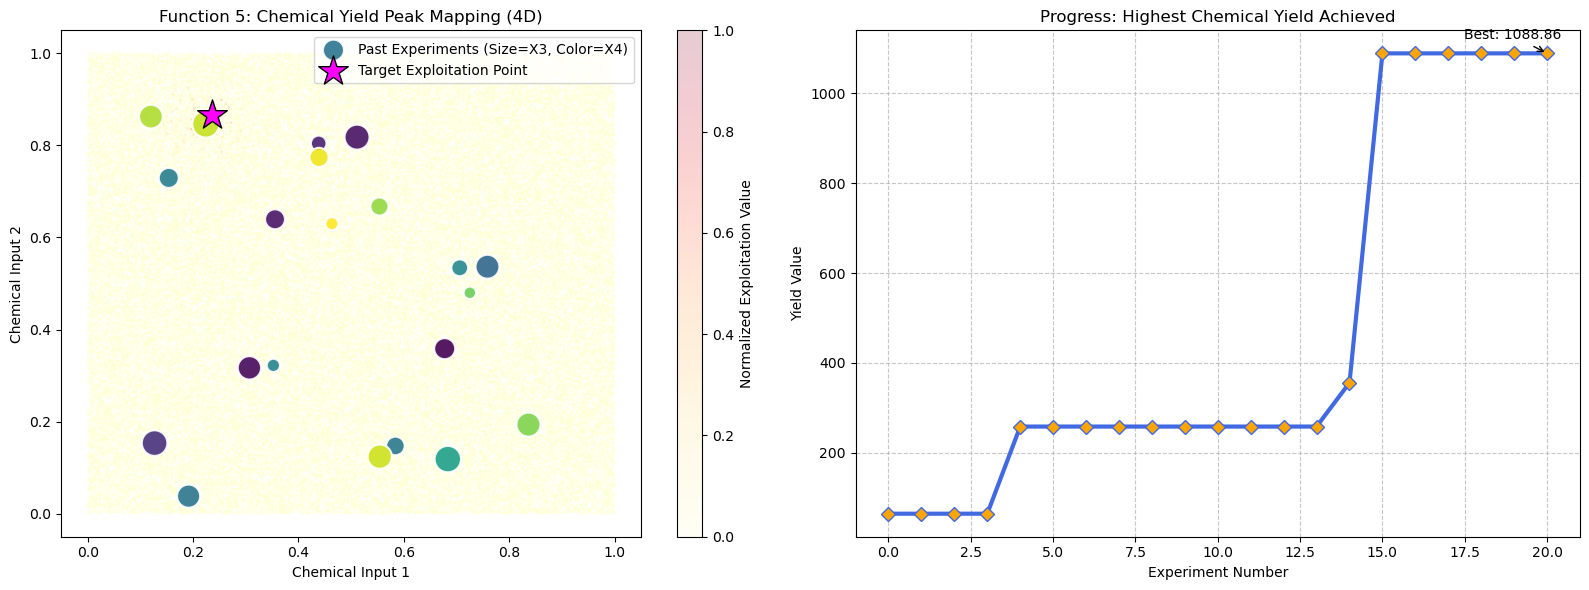

In [8]:
# Setup Progress Tracking
# Function 5 is a maximization problem for chemical yield 
running_max = np.maximum.accumulate(Y_updated)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 4D Projection Parameters
x3_scaled = (X_updated[:, 2] - np.min(X_updated[:, 2])) / (np.ptp(X_updated[:, 2]) + 1e-12)
past_sizes = 80 + (300 * x3_scaled) # Larger markers for clarity in 4D

# The Search Map: Exploitation View
# Background: The Acquisition Function (EI) showing where the model wants to 'fine-tune'
acq_norm = (ei_values - np.nanmin(ei_values)) / (np.nanmax(ei_values) - np.nanmin(ei_values) + 1e-12)

# Plotting the EI hotspots in the first two dimensions
sc = ax1.scatter(x_grid[:, 0], x_grid[:, 1], c=acq_norm, cmap='YlOrRd', s=1, alpha=0.2)
cbar = plt.colorbar(sc, ax=ax1, label='Normalized Exploitation Value')

# Past Samples: Colored by the 4th chemical variable and sized by the 3rd
past_sc = ax1.scatter(X_updated[:, 0], X_updated[:, 1], 
                      c=X_updated[:, 3], 
                      cmap='viridis', 
                      s=past_sizes, 
                      edgecolors='white', 
                      linewidth=1.5,
                      alpha=0.9, 
                      label='Past Experiments (Size=X3, Color=X4)')

# Next Query: The target point for maximizing yield
ax1.scatter(next_query[0], next_query[1], c='magenta', marker='*', s=500, edgecolors='black', label='Target Exploitation Point')

ax1.set_title('Function 5: Chemical Yield Peak Mapping (4D)')
ax1.set_xlabel('Chemical Input 1')
ax1.set_ylabel('Chemical Input 2')
ax1.legend(loc='upper right')

# Progress Plot: Climbing the Unimodal Peak
ax2.plot(running_max, color='royalblue', linewidth=3, marker='D', markersize=7, markerfacecolor='orange')
ax2.set_title('Progress: Highest Chemical Yield Achieved')
ax2.set_xlabel('Experiment Number')
ax2.set_ylabel('Yield Value')
ax2.grid(True, linestyle='--', alpha=0.7)

# Highlighting the value from Week 1 (155.728) 
ax2.annotate(f'Best: {np.max(Y_updated):.2f}', 
             xy=(len(Y_updated)-1, np.max(Y_updated)), 
             xytext=(-60, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()

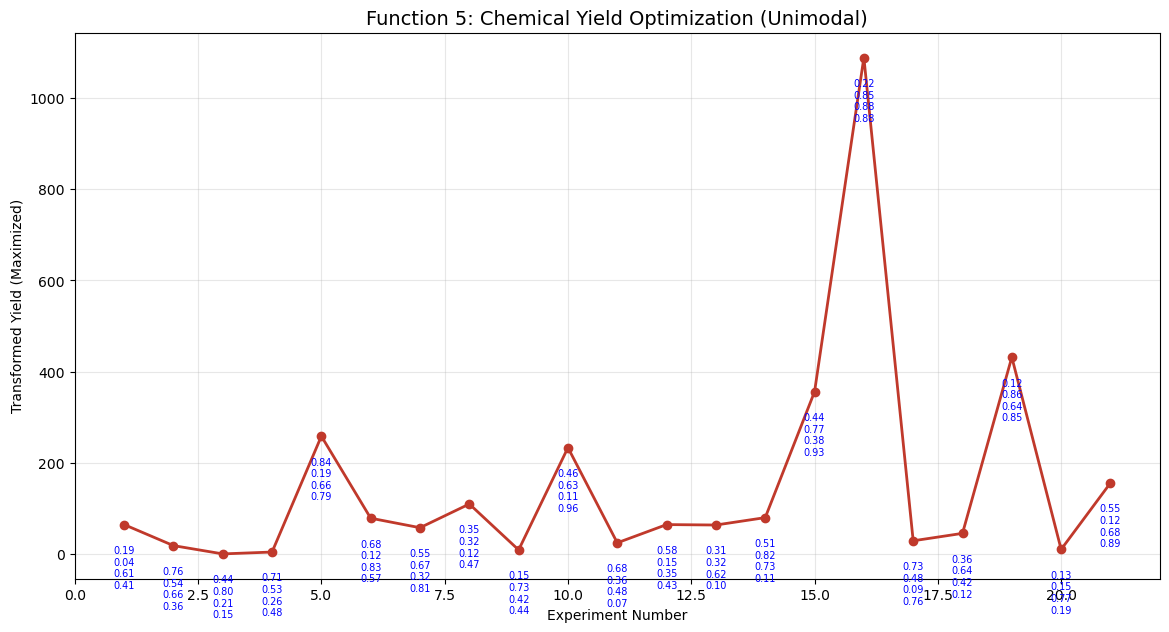

In [9]:
iterations = np.arange(1, len(Y_updated) + 1)
plt.figure(figsize=(14, 7))
plt.plot(iterations, Y_updated, marker='o', linestyle='-', color='#c0392b', linewidth=2)

for i in range(len(Y_updated)):
    # Stacked inputs: x1 (temp), x2 (pressure), x3 (conc), x4 (time)
    input_label = f"{X_updated[i,0]:.2f}\n{X_updated[i,1]:.2f}\n{X_updated[i,2]:.2f}\n{X_updated[i,3]:.2f}"
    
    plt.annotate(input_label, 
                 (iterations[i], Y_updated[i]), 
                 textcoords="offset points", 
                 xytext=(0, -15), 
                 va='top', 
                 ha='center', 
                 fontsize=7,
                 linespacing=1.2,
                 color = 'blue')

plt.title('Function 5: Chemical Yield Optimization (Unimodal)', fontsize=14)
plt.xlabel('Experiment Number')
plt.ylabel('Transformed Yield (Maximized)')
plt.subplots_adjust(bottom=0.1) # Extra space for stacked labels
plt.grid(True, alpha=0.3)
plt.show()